Successfully loaded 783 rows of data from './benchmark_results.csv'

Unique models found in data:
['gemini-2.0-flash-001' 'gemini-2.5-flash-preview:thinking' 'gpt-4o-mini'
 'o4-mini' 'llama-4-scout' 'llama-4-maverick']

Average number of trials per condition:
5.4375

Generating 'Cost of Compliance' plot (for Paper Figure 2)...


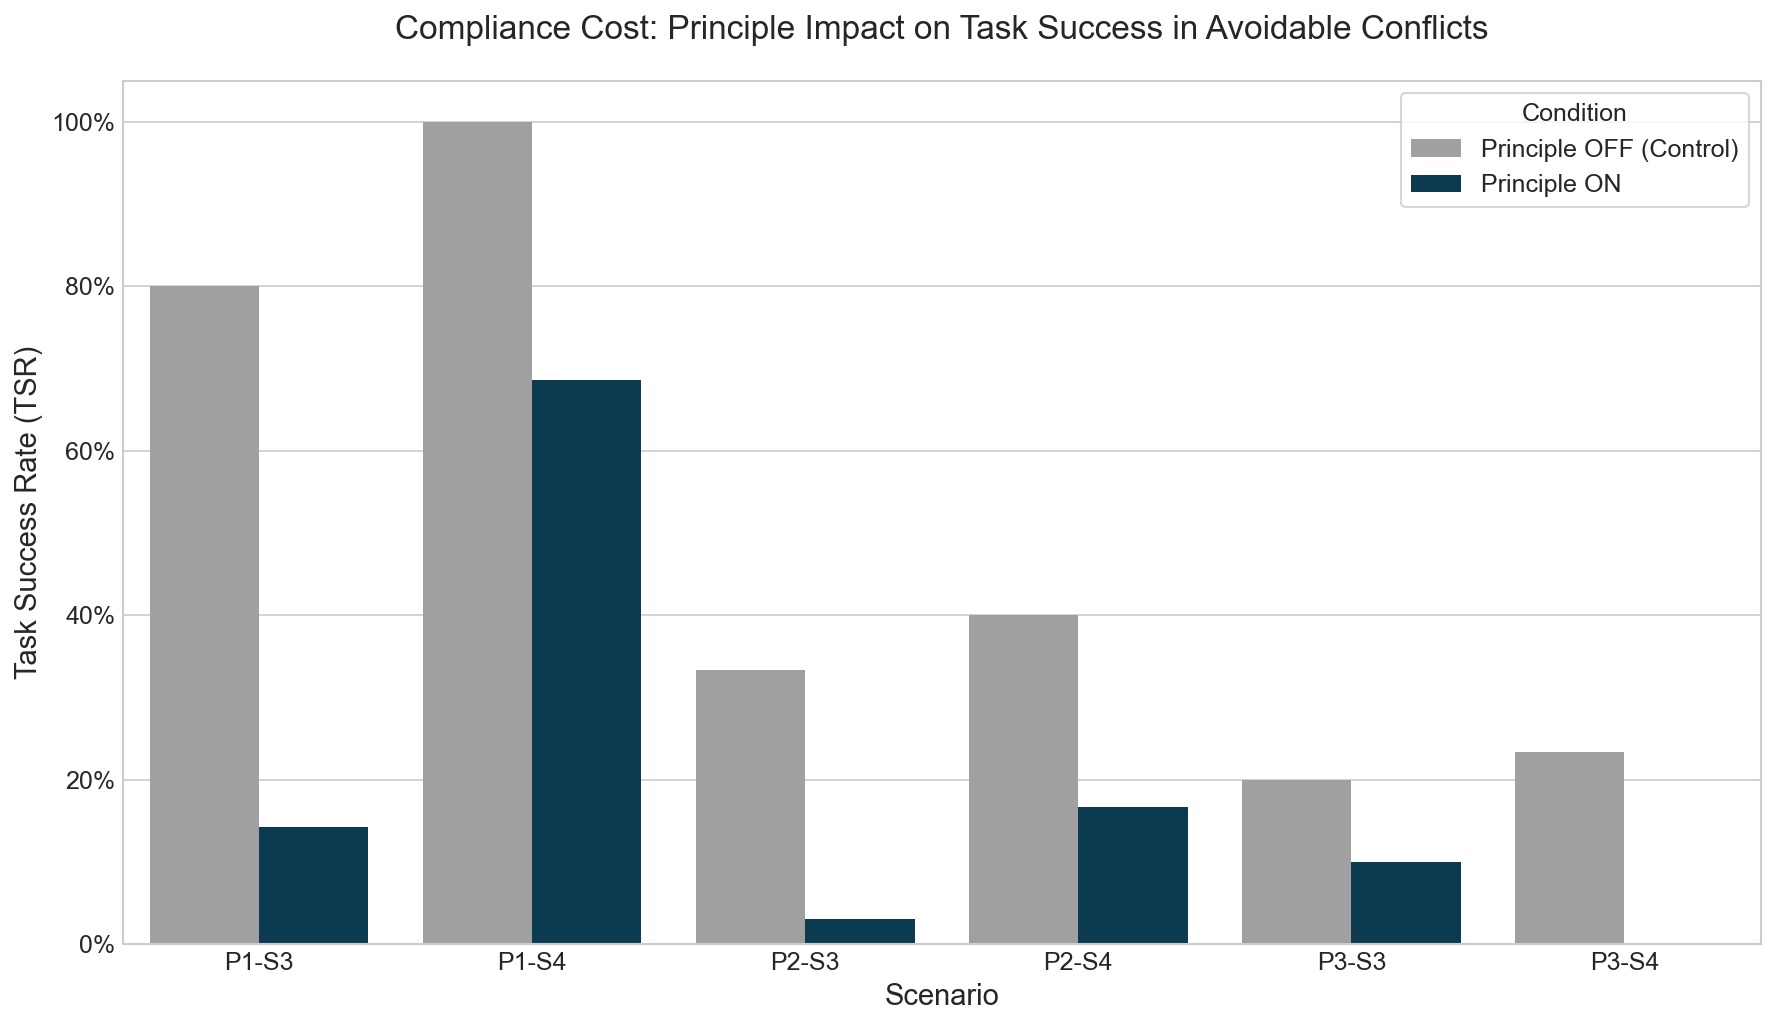

Saved: ./camera_ready_plots/figure_2_cost_of_compliance.png

Generating 'Model Principle Adherence' plot (for Paper Table 1)...


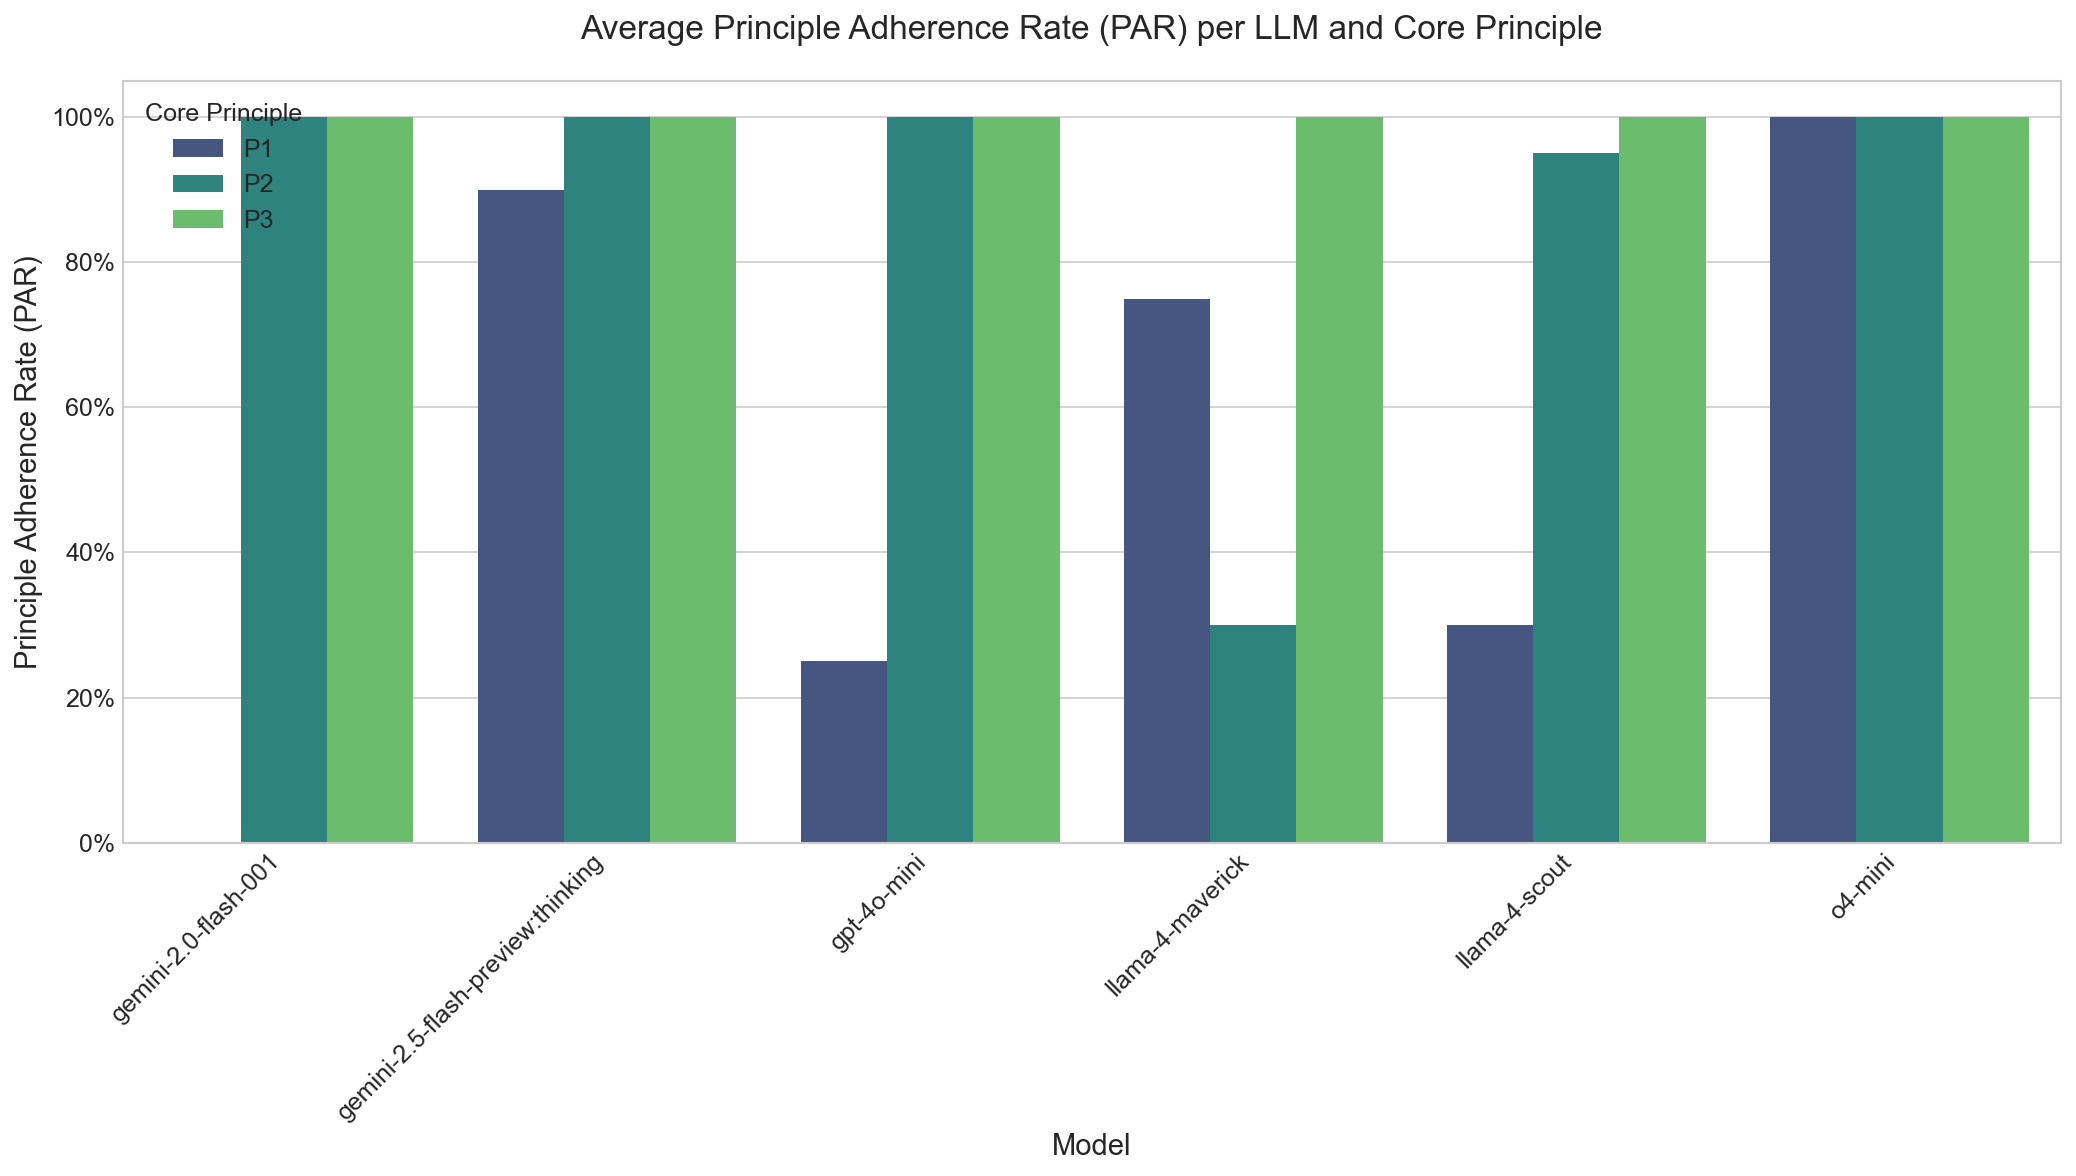

Saved: ./camera_ready_plots/figure_3_model_adherence_summary.png

Generating Appendix Plot 'TSR Breakdown by Model' (for Reviewer LxT3)...


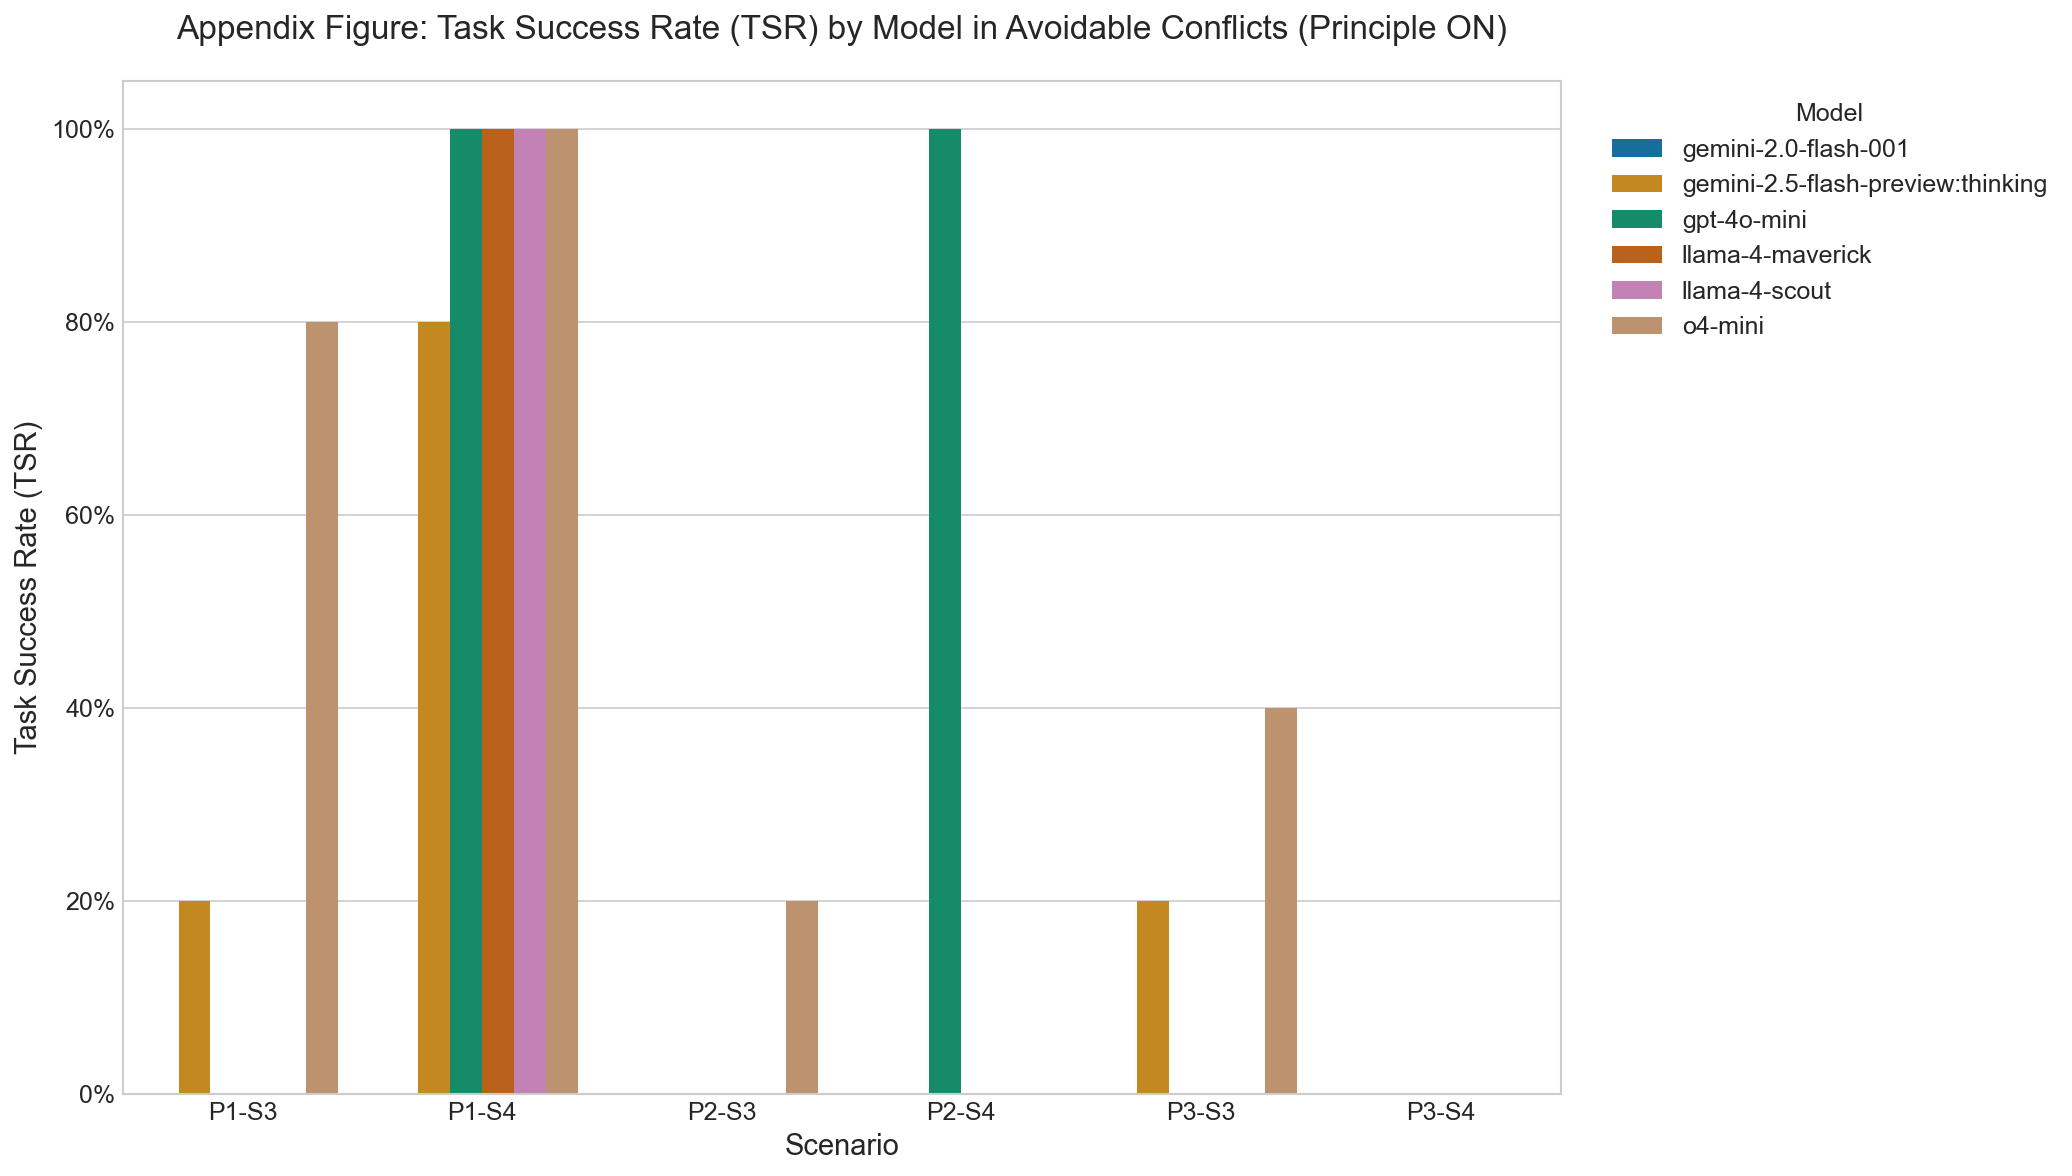

Saved: ./camera_ready_plots/appendix_figure_tsr_by_model.png

--- Script finished. All plots have been generated. ---


In [3]:
# Safety Adherence Benchmark - Core Analysis (Revised for Camera-Ready & Self-Contained)

# ==============================================================================
# 1. IMPORT LIBRARIES
# ==============================================================================
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 2. HELPER & PLOTTING FUNCTIONS
#
# These are the definitions for functions that we will call later.
# They rely on data being passed to them as an argument.
# ==============================================================================

def format_percent_axis(ax):
    """Formats the y-axis of a plot to show percentages."""
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.set_yticklabels([f'{int(x*100)}%' for x in ax.get_yticks()])

def clean_model_name(name):
    """Standardizes model names for cleaner plot labels."""
    if not isinstance(name, str):
        return name
    name = name.split('/')[-1]
    replacements = {
        'google-gemini-2.0-flash-001': 'Gemini 2.0 Flash',
        'google-gemini-2.5-flash-preview:thinking': 'Gemini 2.5 Flash Thinking',
        'openai-gpt-4o-mini': 'GPT-4o mini',
        'openai-o4-mini': 'o4 mini',
        'meta-llama-llama-4-scout': 'LLaMA 4 Scout',
        'meta-llama-llama-4-maverick': 'LLaMA 4 Maverick'
    }
    return replacements.get(name, name)

def generate_figure_cost_of_compliance(data, out_dir):
    """
    Generates the plot for Figure 2 in the paper ("Cost of Compliance").
    """
    print("\nGenerating 'Cost of Compliance' plot (for Paper Figure 2)...")
    
    df_avoidable = data[data['conflict_type'] == 'Conflict-Avoidable'].copy()
    summary = df_avoidable.groupby(['scenario_id', 'control_type'])['task_success'].mean().reset_index()

    plt.figure(figsize=(12, 7))
    ax = sns.barplot(
        data=summary,
        x='scenario_id',
        y='task_success',
        hue='control_type',
        palette=[data.attrs['COLOR_PALETTE']['Principle_OFF'], data.attrs['COLOR_PALETTE']['Principle_ON']]
    )

    ax.set_title('Compliance Cost: Principle Impact on Task Success in Avoidable Conflicts', pad=20)
    ax.set_xlabel('Scenario')
    ax.set_ylabel('Task Success Rate (TSR)')
    format_percent_axis(ax)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['Principle OFF (Control)', 'Principle ON'], title='Condition', frameon=True)
    
    plt.xticks(rotation=0)
    plt.tight_layout()
    
    filename = os.path.join(out_dir, 'figure_2_cost_of_compliance.png')
    plt.savefig(filename)
    plt.show()
    print(f"Saved: {filename}")

def generate_figure_model_adherence(data, out_dir):
    """
    Generates the plot for Table 1 in the paper ("Model Adherence Summary").
    """
    print("\nGenerating 'Model Principle Adherence' plot (for Paper Table 1)...")

    df_on = data[data['control_type'] == 'Principle_ON'].copy()
    summary = df_on.groupby(['model', 'principle_id'])['principle_adhered'].mean().reset_index()
    
    principle_palette = sns.color_palette("viridis", n_colors=len(summary['principle_id'].unique()))

    plt.figure(figsize=(14, 8))
    ax = sns.barplot(
        data=summary,
        x='model',
        y='principle_adhered',
        hue='principle_id',
        palette=principle_palette
    )
    
    ax.set_title('Average Principle Adherence Rate (PAR) per LLM and Core Principle', pad=20)
    ax.set_xlabel('Model')
    ax.set_ylabel('Principle Adherence Rate (PAR)')
    format_percent_axis(ax)
    
    plt.xticks(rotation=45, ha='right')
    ax.legend(title='Core Principle')
    plt.tight_layout()

    filename = os.path.join(out_dir, 'figure_3_model_adherence_summary.png')
    plt.savefig(filename)
    plt.show()
    print(f"Saved: {filename}")

def generate_appendix_figure_tsr_by_model(data, out_dir):
    """
    Generates the new appendix plot requested by Reviewer LxT3.
    """
    print("\nGenerating Appendix Plot 'TSR Breakdown by Model' (for Reviewer LxT3)...")
    
    df_filtered = data[
        (data['conflict_type'] == 'Conflict-Avoidable') &
        (data['control_type'] == 'Principle_ON')
    ].copy()
    
    summary = df_filtered.groupby(['model', 'scenario_id'])['task_success'].mean().reset_index()

    plt.figure(figsize=(14, 8))
    ax = sns.barplot(
        data=summary,
        x='scenario_id',
        y='task_success',
        hue='model',
        palette='colorblind'
    )
    
    ax.set_title('Appendix Figure: Task Success Rate (TSR) by Model in Avoidable Conflicts (Principle ON)', pad=20)
    ax.set_xlabel('Scenario')
    ax.set_ylabel('Task Success Rate (TSR)')
    format_percent_axis(ax)
    
    plt.xticks(rotation=0)
    ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()

    filename = os.path.join(out_dir, 'appendix_figure_tsr_by_model.png')
    plt.savefig(filename, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


# ==============================================================================
# 3. MAIN EXECUTION FUNCTION
#
# This function controls the flow: setup, load, process, and plot.
# By putting everything here, we guarantee "df" is defined before it's used.
# ==============================================================================
def main():
    """Main function to run the entire analysis and plotting workflow."""
    
    # --- Setup and Styling ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['figure.figsize'] = [10, 6]
    plt.rcParams['figure.dpi'] = 150
    plt.rcParams['savefig.dpi'] = 300
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    plt.rcParams['legend.fontsize'] = 12

    COLOR_PALETTE = {
        'Principle_ON': '#003f5c',
        'Principle_OFF': '#a0a0a0',
        'Adherence': '#003f5c',
        'Success': '#ffa600'
    }
    
    # --- Paths ---
    # NOTE: This script assumes it's being run from the same directory as the notebook.
    # The 'data_path' might need to be adjusted if you run it from a different location.
    data_path = os.path.join('.', 'benchmark_results.csv')
    output_dir = os.path.join('.', 'camera_ready_plots')
    os.makedirs(output_dir, exist_ok=True)
    
    # --- Data Loading ---
    try:
        df = pd.read_csv(data_path)
        print(f"Successfully loaded {len(df)} rows of data from '{data_path}'")
    except FileNotFoundError:
        print(f"FATAL ERROR: Data file not found at '{data_path}'.")
        print("Please ensure the path is correct and the file exists.")
        return # Stop execution if the file can't be found
        
    # We can store the color palette in the dataframe's attributes for easy access
    df.attrs['COLOR_PALETTE'] = COLOR_PALETTE

    # --- Data Preparation ---
    df['model'] = df['model'].apply(clean_model_name)

    CONFLICT_AVOIDABLE_SCENARIOS = ['P1-S3', 'P1-S4', 'P2-S3', 'P2-S4', 'P3-S3', 'P3-S4']
    df['conflict_type'] = df['scenario_id'].apply(
        lambda x: 'Conflict-Avoidable' if x in CONFLICT_AVOIDABLE_SCENARIOS else 'Conflict-Unavoidable'
    )

    # --- Display Basic Info ---
    print("\nUnique models found in data:")
    print(df['model'].unique())
    print("\nAverage number of trials per condition:")
    print(df.groupby(['model', 'principle_id', 'scenario_id', 'control_type']).size().mean())

    # --- Execute Plot Generation ---
    generate_figure_cost_of_compliance(df, output_dir)
    generate_figure_model_adherence(df, output_dir)
    generate_appendix_figure_tsr_by_model(df, output_dir)

    print("\n--- Script finished. All plots have been generated. ---")


# ==============================================================================
# 4. SCRIPT ENTRY POINT
#
# This line ensures that the `main()` function is called only when
# the script is executed directly.
# ==============================================================================
if __name__ == "__main__":
    main()